Packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import wrds

Data sourcing:

In [2]:
db = wrds.Connection(wrds_username='lucadesj')


Loading library list...
Done


In [3]:
# Extract fundamentals annual
# Table : comp.funda

compustat_query = """
    SELECT
        gvkey, datadate, fyear, indfmt,
        conm,
        -- Compte de résultat
        sale, ebit, oibdp, dp, ni, txt, xint, oancf, capx, cogs, revt,
        -- Bilan
        at, ceq, dltt, dlc, che, lct,
        -- Actions & prix
        csho, prcc_f,
        -- Intangible
        xrd, xsga
    FROM comp.funda
    WHERE fyear BETWEEN 2000 AND 2025
      AND indfmt  = 'INDL'
      AND datafmt = 'STD'
      AND popsrc  = 'D'
      AND consol  = 'C'
      AND sale > 0
      AND at   > 0
      AND ceq  > 0
"""


db_comp = db.raw_sql(compustat_query, date_cols=['datadate'])
db_comp = db_comp.drop_duplicates(["gvkey", "fyear"])
db_comp.head()

,gvkey,datadate,fyear,indfmt,conm,sale,ebit,oibdp,dp,ni,...,at,ceq,dltt,dlc,che,lct,csho,prcc_f,xrd,xsga
0,001004,2001-05-31,2000,INDL,AAR CORP,874.255,45.79,64.367,18.577,18.531,...,701.854,340.212,179.987,13.652,13.809,125.392,26.937,14.0,<NA>,96.077
1,001010,2000-12-31,2000,INDL,ACF INDUSTRIES INC,443.8,117.0,178.7,61.7,79.9,...,3794.5,985.2,1866.8,176.1,113.0,<NA>,0.015,<NA>,<NA>,32.4
2,001013,2000-10-31,2000,INDL,ADC TELECOMMUNICATIONS INC,3287.9,523.9,670.1,146.2,868.1,...,3970.5,2912.7,16.5,28.5,1354.2,1041.3,770.3,21.375,338.0,1050.7
3,001019,2000-12-31,2000,INDL,AFA PROTECTIVE SYSTEMS INC,42.504,3.415,5.443,2.028,1.762,...,28.638,13.184,1.12,0.666,1.818,5.39,0.166,183.0,<NA>,12.554
4,001021,2000-06-30,2000,INDL,AFP IMAGING CORP,25.367,-0.028,0.672,0.7,-0.808,...,11.608,4.455,4.875,0.195,0.434,2.278,9.271,0.49,0.477,8.189


In [4]:
# Extract Monthly Price
# Table : crsp.msf 

crsp_query = """
   SELECT
    m.permno,
    m.date,
    m.prc,
    m.ret,
    m.retx,   
    m.shrout,
    n.siccd,
    n.shrcd,
    n.exchcd
FROM crsp.msf AS m
JOIN crsp.msenames AS n
    ON m.permno = n.permno
    AND m.date BETWEEN n.namedt AND n.nameendt
WHERE n.shrcd IN (10, 11)        -- Actions ordinaires uniquement
    AND n.exchcd IN (1, 2, 3)    -- NYSE, AMEX, et NASDAQ
    AND m.date >= '2000-01-01'
"""
db_crsp = db.raw_sql(crsp_query, date_cols=['date'])
db_crsp['date'] = db_crsp['date'] + pd.offsets.MonthEnd(0) #Ramène chaque date à la fin du mois
db_crsp.head()

,permno,date,prc,ret,retx,shrout,siccd,shrcd,exchcd
0,10066,2000-01-31,2.0,-0.2,-0.2,28258.0,4813,11,2
1,10066,2000-02-29,2.0,0.0,0.0,29020.0,4813,11,2
2,10066,2000-03-31,2.125,0.0625,0.0625,29020.0,4813,11,2
3,10066,2000-04-30,1.3125,-0.382353,-0.382353,29020.0,4813,11,2
4,10066,2000-05-31,0.9375,-0.285714,-0.285714,34530.0,4813,11,2


In [5]:
test_query = """ 
    SELECT 
        permno, 
        dlstdt, 
        dlret, 
        dlstcd, 
        dlprc 
    FROM crsp.msedelist
    WHERE dlstdt >= '2000-01-01'
"""

db_dl = db.raw_sql(test_query, date_cols=['dlstdt'])
db_dl['date'] = db_dl['dlstdt'] + pd.offsets.MonthEnd(0)
db_dl.head()

,permno,dlstdt,dlret,dlstcd,dlprc,date
0,10001,2017-08-03,0.011583,233,0.0,2017-08-31
1,10002,2013-02-15,0.046007,231,0.0,2013-02-28
2,10009,2000-11-03,0.005671,233,0.0,2000-11-30
3,10012,2005-08-02,-0.058824,552,0.16,2005-08-31
4,10016,2001-05-03,-0.028936,231,0.0,2001-05-31


In [6]:
db_crsp = db_crsp.merge(
    db_dl[['permno', 'date', 'dlret', 'dlstcd', 'dlprc']],
    on=['permno', 'date'],
    how='left')

In [7]:
# Trouver le dernier mois de chaque permno dans le CRSP
last_obs = db_crsp.groupby('permno')['date'].max().reset_index(name='last_date')

orphan_dl = db_dl.merge(last_obs, on='permno')
orphan_dl = orphan_dl[orphan_dl['date'] > orphan_dl['last_date']].copy()

# Calculer le gap en mois entre dlstdt et le dernier mois dans msf
orphan_dl['gap_months'] = (
    (orphan_dl['date'].dt.year - orphan_dl['last_date'].dt.year) * 12
    + (orphan_dl['date'].dt.month - orphan_dl['last_date'].dt.month)
)

orphan_valid = orphan_dl[orphan_dl['gap_months'] <= 6]  

if not orphan_valid.empty:
    db_crsp = db_crsp.merge(
        orphan_valid[['permno', 'last_date', 'dlret', 'dlstcd', 'dlprc']]
              .rename(columns={'last_date': 'date',
                               'dlret': 'dlret_orphan',
                               'dlstcd': 'dlstcd_orphan',
                               'dlprc': 'dlprc_orphan'}),
        on=['permno', 'date'],
        how='left'
    )
    db_crsp['dlret']  = db_crsp['dlret'].fillna(db_crsp['dlret_orphan'])
    db_crsp['dlstcd'] = db_crsp['dlstcd'].fillna(db_crsp['dlstcd_orphan'])
    db_crsp['dlprc']  = db_crsp['dlprc'].fillna(db_crsp['dlprc_orphan'])
    db_crsp.drop(columns=['dlret_orphan', 'dlstcd_orphan', 'dlprc_orphan'], inplace=True)


In [8]:
print(db_comp.shape)
print(db_crsp.shape)

(178725, 26)
(1294973, 12)


In [9]:
#Link table :
link_query = """
    SELECT gvkey, lpermno AS permno, linkdt, linkenddt
    FROM crsp.ccmxpf_lnkhist
    WHERE linktype IN ('LC', 'LU')
      AND linkprim IN ('P', 'C')
"""

db_link = db.raw_sql(link_query, date_cols=['linkdt', 'linkenddt'])
db_link['linkenddt'] = db_link['linkenddt'].fillna(pd.Timestamp('2099-12-31')) #Remplace les NaN par une date fictive future (lien encore actif)

db_link.head()

,gvkey,permno,linkdt,linkenddt
0,001000,25881.0,1970-11-13,1978-06-30
1,001001,10015.0,1983-09-20,1986-07-31
2,001002,10023.0,1972-12-14,1973-06-05
3,001003,10031.0,1983-12-07,1989-08-16
4,001004,54594.0,1972-04-24,2099-12-31


In [10]:
#Panel final

#Prise en compte du décalage entre les données et la date de clôture de l'année fiscale 
db_comp['avail_date'] = (db_comp['datadate'] + pd.DateOffset(months=6)) + pd.offsets.MonthEnd(0)

#Conservation des dates valides uniquement
crsp_linked = db_crsp.merge(db_link, on='permno', how='inner')

crsp_linked = crsp_linked[
    (crsp_linked['date'] >= crsp_linked['linkdt']) &
    (crsp_linked['date'] <= crsp_linked['linkenddt'])].drop(columns=['linkdt', 'linkenddt']) #Ne garde uniquement les valeurs comprises dans l'interval de validité du lien des "keys"


#Liaison entre chaque mois du CRSP et le dernier exercice Compustat dispo 

crsp_linked['date'] = pd.to_datetime(crsp_linked['date'])
db_comp['avail_date'] = pd.to_datetime(db_comp['avail_date'])

crsp_linked = crsp_linked.sort_values(['gvkey', 'date'])
db_comp = db_comp.sort_values(['gvkey', 'avail_date'])

In [11]:
import psutil
print(f"RAM utilisée : {psutil.virtual_memory().percent}%")
print(f"Swap utilisé : {psutil.swap_memory().percent}%")

RAM utilisée : 28.8%
Swap utilisé : 0.0%


In [12]:
# Merge sur gvkey 
temp = crsp_linked.merge(
    db_comp[['gvkey', 'avail_date', 'fyear', 'conm', 'indfmt', 'ni', 'ceq', 'oancf', 'sale', 
             'ebit', 'oibdp', 'dp', 'txt', 'xint', 'capx', 'revt','cogs', 'at', 'dltt', 
             'dlc', 'che', 'lct', 'csho', 'prcc_f', 'xrd', 'xsga']],
    on='gvkey', 
    how='left', 
    suffixes=('', '_comp')
)

# On garde uniquement les lignes où date CRSP <= date dispo comptes
temp = temp[temp['avail_date'] <= temp['date']]

# Pour chaque (gvkey, date CRSP), on prend le compte le plus récent disponible
panel = (temp
    .sort_values(['gvkey', 'date', 'avail_date'], ascending=[True, True, False])
    .groupby(['gvkey', 'date'])
    .first()
    .reset_index())

# Nettoyage des doublons colonnes
panel = panel.drop(columns=['avail_date_comp'], errors='ignore')

print(f"Panel : {panel.shape[0]:,}  obs — {panel['permno'].nunique():,} titres")


Panel : 1,099,674  obs — 10,387 titres


In [13]:
panel.head()

,gvkey,date,permno,prc,ret,retx,shrout,siccd,shrcd,exchcd,...,cogs,at,dltt,dlc,che,lct,csho,prcc_f,xrd,xsga
0,001004,2001-11-30,54594,8.15,0.072368,0.072368,26958.0,5088,11,1,...,713.811,701.854,179.987,13.652,13.809,125.392,26.937,14.0,<NA>,96.077
1,001004,2001-12-31,54594,9.01,0.105522,0.105522,26958.0,5088,11,1,...,713.811,701.854,179.987,13.652,13.809,125.392,26.937,14.0,<NA>,96.077
2,001004,2002-01-31,54594,8.6,-0.04273,-0.045505,26859.0,5088,11,1,...,713.811,701.854,179.987,13.652,13.809,125.392,26.937,14.0,<NA>,96.077
3,001004,2002-02-28,54594,7.4,-0.139535,-0.139535,26860.0,5088,11,1,...,713.811,701.854,179.987,13.652,13.809,125.392,26.937,14.0,<NA>,96.077
4,001004,2002-03-31,54594,10.77,0.455405,0.455405,26860.0,5088,11,1,...,713.811,701.854,179.987,13.652,13.809,125.392,26.937,14.0,<NA>,96.077


Traitement des NaN:

In [14]:
#Remplacement par 0 
zero_fill = ['xrd', 'capx', 'dp', 'txt', 'xint']
panel[zero_fill] = panel[zero_fill].fillna(0)

In [15]:
#Remplacement par lissage vers l'avant (ou l'arrière si pas dispo)
balance_sheet = ['dltt', 'dlc']
for col in balance_sheet:
    panel[col] = (panel
                  .groupby('gvkey')[col]
                  .ffill()
                  .bfill()
                  .fillna(0))

In [16]:
#Traitement des valeurs manquantes lct (current liabilities) 
print(db_comp['indfmt'].value_counts()) #Contrôle pour vérifier s'il reste des banques

lct_missing = panel.groupby('gvkey')['lct'].apply(lambda x: x.isna().mean())
print("LCT manquants par gvkey :")
print(lct_missing.describe()) #moyenne de manquement correct

bad_lct = lct_missing[lct_missing > 0.8].index.tolist()
print(f"Entreprises LCT >80% manquant : {len(bad_lct)}") #Résultat : 1806, résultat attendu (correspond aux PME sans passif)

panel['lct'] = (panel
                .groupby('gvkey')['lct']
                .ffill()
                .bfill()
                .fillna(0))

indfmt
INDL    178725
Name: count, dtype: Int64
LCT manquants par gvkey :
count    10308.000000
mean         0.172187
std          0.376274
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: lct, dtype: float64
Entreprises LCT >80% manquant : 1756


In [17]:
#Traitement des valeurs manquantes oibdp (Operatinf Income before Depreciation

oibdp_missing = panel.groupby('gvkey')['oibdp'].apply(lambda x: x.isna().mean())
oibdp_missing.describe()

bad_oibdp = oibdp_missing[oibdp_missing == 1].index.tolist() 
print(len(bad_oibdp))

bad_companies = panel[panel['gvkey'].isin(bad_oibdp)][['gvkey', 'conm']].drop_duplicates()
print(bad_companies) 

# 25 entreprises sur des secteurs diversifiés, on fait le choix de les exclures de notre sample

panel = panel[~panel['gvkey'].isin(bad_oibdp)]

panel['oibdp'] = (panel
                .groupby('gvkey')['oibdp']
                .ffill()
                .bfill())

15
          gvkey                          conm
10665    001465         AMERICAN GENERAL CORP
56084    003230       COMDISCO HOLDING CO INC
304691   013532           MERCHANTS GROUP INC
384999   018792        GAMING & LEISURE PPTYS
397671   019717                 NEUROGENE INC
499927   026020           ANTEX BIOLOGICS INC
504697   026410  FOUR CORNERS PROPERTY TR INC
506823   026839      PHILLIPS EDISON & CO INC
509718   027394         PARK HOTELS & RESORTS
617577   035305                  VERICITY INC
632446   038753            ENACT HOLDINGS INC
728650   064365     GOLF TRUST OF AMERICA INC
733120   064597         PEREGRINE SYSTEMS INC
841905   122435                MIIX GROUP INC
1012799  174551         MANIFOLD CAPITAL CORP


In [18]:
#Traitement des valeurs manquantes xsga (Selling, General and Administrative Expenses)

# xsga = Revenue - COGS - Depreciation - Op. Income

panel['xsga'] = panel['xsga'].fillna(panel['revt'] - panel['cogs'] - panel['oibdp'])


In [19]:
#Traitement des valeurs manquantes oancf (Operating Activity - Net Cash Flow)

oancf_missing = panel.groupby('gvkey')['oancf'].apply(lambda x: x.isna().mean())
oancf_missing.describe()

bad_oancf = oancf_missing[oancf_missing == 1].index.tolist() 
print(len(bad_oancf))

bad_companies1 = panel[panel['gvkey'].isin(bad_oancf)][['gvkey', 'conm']].drop_duplicates() #on s'aperçoit que le filtre INDL au moment de la query n'a pas bien fonctionné car la 
                                                                                            #plupart des entreprises sont ici des banques
print(bad_companies1) 

#Par soucis de simplicité, et comme ce sont majoritairement des banques, on drop 

panel = panel[~panel['gvkey'].isin(bad_oancf)]

#Le peu de valeurs manquantes restant (407) sont lissées

panel['oancf'] = (panel
                .groupby('gvkey')['oancf']
                .ffill()
                .bfill())


235
         gvkey                         conm
25198   001998                BANK ONE CORP
25801   002007         FIRST BANKS AMER INC
94496   004708                BANCWEST CORP
95176   004742     FIRST VIRGINIA BANKS INC
95537   004764   FLEETBOSTON FINANCIAL CORP
...        ...                          ...
882141  137378     FIRST SHARES BANCORP INC
882639  137531     DUTCHFORK BANCSHARES INC
885886  138128           PACIFIC UNION BANK
907406  143463  CHESTERFIELD FINANCIAL CORP
950709  157973   FIRST NATL BANKSHRS FL INC

[235 rows x 2 columns]


In [20]:
#Traitement des valeurs manquantes ebit 

# EBIT = OIBDP - DP

panel['ebit'] = panel['ebit'].fillna(panel['oibdp'] - panel['dp'])

In [21]:
#Traitement des valeurs manquantes csho (Common Share Outstanding)

# csho (compustat) peut être rapproché à shrout (CRSP), seulement dans la documentation respective on voit que l'unité est traité différemment

# csho = shrout / 1000 

panel['csho'] = panel['csho'].fillna(panel['shrout'] / 1000) 

#l'utilité de garder les deux peuvent être discuté. Cependant, en réalité elles sont différentes d'un point de vue comptable (ici on a simplifié pour le peu de valeur manquantes (400)

In [22]:
#Traitement des prc manquants
panel = panel.sort_values(['permno', 'date']).reset_index(drop=True)

# Groupes de NaN consécutifs par permno
panel['_prc_null'] = panel['prc'].isna().astype(int)

# Longueur max de la séquence de NaN consécutifs pour chaque permno
panel['_gap_id'] = (panel.groupby('permno')['_prc_null'].transform(lambda x: (x != x.shift()).cumsum()))

panel['_gap_size'] = (panel.groupby(['permno', '_gap_id'])['_prc_null'].transform('sum'))

# Appliquer ffill uniquement aux permnos dont le gap max est < 4
permno_ffill = set(panel[panel['_prc_null'] == 1]
    .groupby('permno')['_gap_size']
    .max()
    .loc[lambda x: x < 3]
    .index)

filtre_ffill = panel['prc'].isna() & panel['permno'].isin(permno_ffill)

panel.loc[panel['permno'].isin(permno_ffill), 'prc'] = (panel.loc[panel['permno'].isin(permno_ffill)].groupby('permno')['prc'].ffill().values)

panel.drop(columns=['_prc_null', '_gap_id', '_gap_size'], inplace=True)

# Remplacer prc manquant par dlprc s'il est disponible 

filtre_dlprc = panel['prc'].isna() & panel['dlprc'].notna()

panel.loc[filtre_dlprc, 'prc'] = panel.loc[filtre_dlprc, 'dlprc']


# Traitement des prcc_f (prix à la clôture de l'année fiscale)

filtre_prccf = panel['prcc_f'].isna() & panel['prc'].notna()

panel.loc[filtre_prccf, 'prcc_f'] = panel.loc[filtre_prccf, 'prc']

In [24]:
#Traitement des valeurs manquantes des returns et prise en compte du Survivorship Bias

panel = panel.sort_values(['permno', 'date']).reset_index(drop=True)

#Suppression des premières observations (ret incalculable sans prc_lag)
panel['first_date'] = panel.groupby('permno')['date'].transform('min')

filtre_drop = (
    (panel['date'] == panel['first_date']) &
    panel['ret'].isna())

panel = panel[~filtre_drop].reset_index(drop=True)
panel.drop(columns=['first_date'], inplace=True)


#Traitement des trous au milieu des séries

panel['_prc']     = panel['prc'].abs()
panel['_prc_lag'] = panel.groupby('permno')['_prc'].shift(1)

# Identifier première et dernière observation de chaque permno
panel['first_date'] = panel.groupby('permno')['date'].transform('min')
panel['last_date']  = panel.groupby('permno')['date'].transform('max')

filtre_trous = (
    panel['ret'].isna() &
    (panel['date'] != panel['first_date']) &
    (panel['date'] != panel['last_date']) &
    panel['_prc'].notna() &
    panel['_prc_lag'].notna() &
    (panel['_prc_lag'] != 0))

panel.loc[filtre_trous, 'ret'] = (panel.loc[filtre_trous, '_prc'] / panel.loc[filtre_trous, '_prc_lag'] - 1)

panel.drop(columns=['_prc', '_prc_lag', 'first_date', 'last_date'], inplace=True)



# Remplacer ret manquant par dlret s'il est disponible 

filtre_dlret = panel['ret'].isna() & panel['dlret'].notna()

panel.loc[filtre_dlret, 'ret'] = panel.loc[filtre_dlret, 'dlret']


# Identifier les permnos ayant encore des prc manquants

permno_prc_manquant = set(panel[panel['prc'].isna()]['permno'].unique())
panel = panel[~panel['permno'].isin(permno_prc_manquant)].reset_index(drop=True)



#Supprimer les erreurs de la base de données 

panel['last_date'] = panel.groupby('permno')['date'].transform('max')

filtre_last_na = (panel['date'] == panel['last_date']) & panel['ret'].isna()

panel = panel[~filtre_last_na].reset_index(drop=True)
panel.drop(columns=['last_date'], inplace=True)


#Traitement des retx
filtre_retx = panel['retx'].isna() & panel['ret'].notna()

panel.loc[filtre_retx, 'retx'] = panel.loc[filtre_retx, 'ret']


In [25]:
panel.isna().sum()

gvkey               0
date                0
permno              0
prc                 0
ret                 0
retx                0
shrout              0
siccd               0
shrcd               0
exchcd              0
dlret         1084162
dlstcd        1080766
dlprc         1080766
avail_date          0
fyear               0
conm                0
indfmt              0
ni                  0
ceq                 0
oancf               0
sale                0
ebit                0
oibdp               0
dp                  0
txt                 0
xint                0
capx                0
revt                0
cogs                0
at                  0
dltt                0
dlc                 0
che                 0
lct                 0
csho                0
prcc_f              0
xrd                 0
xsga                0
dtype: int64

In [26]:
#Suppression des colonnes inutiles

panel.drop(columns=['dlret', 'dlstcd', 'dlprc'], inplace=True)

In [27]:
#Visualisation de la DB

panel

,gvkey,date,permno,prc,ret,retx,shrout,siccd,shrcd,exchcd,...,cogs,at,dltt,dlc,che,lct,csho,prcc_f,xrd,xsga
0,012994,2000-12-31,10001,9.75,0.03268,0.019608,2498.0,4920,11,3,...,67.2,50.553,16.395,5.3,0.112,14.841,2.475,8.0,0.0,-0.0
1,012994,2001-01-31,10001,9.875,0.012821,0.012821,2498.0,4920,11,3,...,67.2,50.553,16.395,5.3,0.112,14.841,2.475,8.0,0.0,-0.0
2,012994,2001-02-28,10001,9.75,-0.012658,-0.012658,2504.0,4920,11,3,...,67.2,50.553,16.395,5.3,0.112,14.841,2.475,8.0,0.0,-0.0
3,012994,2001-03-31,10001,10.0,0.038462,0.025641,2509.0,4920,11,3,...,67.2,50.553,16.395,5.3,0.112,14.841,2.475,8.0,0.0,-0.0
4,012994,2001-04-30,10001,9.75,-0.025,-0.025,2509.0,4920,11,3,...,67.2,50.553,16.395,5.3,0.112,14.841,2.475,8.0,0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090632,184996,2024-08-31,93436,214.11,-0.077391,-0.077391,3194640.0,9999,11,3,...,74446.0,106618.0,6528.0,3045.0,29637.0,28748.0,3185.0,248.48,3969.0,8769.0
1090633,184996,2024-09-30,93436,261.63,0.221942,0.221942,3207000.0,9999,11,3,...,74446.0,106618.0,6528.0,3045.0,29637.0,28748.0,3185.0,248.48,3969.0,8769.0
1090634,184996,2024-10-31,93436,249.85001,-0.045025,-0.045025,3210060.0,9999,11,3,...,74446.0,106618.0,6528.0,3045.0,29637.0,28748.0,3185.0,248.48,3969.0,8769.0
1090635,184996,2024-11-30,93436,345.16,0.381469,0.381469,3210060.0,9999,11,3,...,74446.0,106618.0,6528.0,3045.0,29637.0,28748.0,3185.0,248.48,3969.0,8769.0


Création des ratios :

In [28]:
# Ratio sans traitement particulier

# Market Cap 
panel['Market Cap'] = abs(panel['prc']) * panel['shrout'] / 1000

# Dette nette 
panel['net_debt'] = panel['dltt'] + panel['dlc'] - panel['che']

# Enterprise Value 
panel['EV'] = panel['Market Cap'] + panel['net_debt']


In [29]:
 
# ============================================================
# Intangible capital directly within panel
# ============================================================

# Parameters
DELTA_K = 0.20   # depreciation rate of knowledge capital
DELTA_O = 0.40   # depreciation rate of organization capital
LAMBDA_O = 0.30  # share of SG&A treated as organizational investment


# ------------------------------------------------------------
# 1) Sort panel properly
# ------------------------------------------------------------
# We sort so that, within each gvkey-fyear, the "last" row is the
# latest relevant monthly observation carrying that annual accounting info.

panel = panel.sort_values(['gvkey', 'fyear', 'date', 'avail_date', 'date']).reset_index(drop=True)


# ------------------------------------------------------------
# 2) Mark the last monthly row for each gvkey-fyear
# ------------------------------------------------------------
# This row will be the only one used to build annual KC and OC.

panel['is_last_firmyear_row'] = (
    panel.groupby(['gvkey', 'fyear']).cumcount()
    == panel.groupby(['gvkey', 'fyear'])['gvkey'].transform('size') - 1
)


# ------------------------------------------------------------
# 3) Build organizational investment only on the retained annual rows
# ------------------------------------------------------------

panel['org_investment'] = np.where(
    panel['is_last_firmyear_row'],
    LAMBDA_O * panel['xsga'],
    np.nan
)


# ------------------------------------------------------------
# 4) Initialize KC and OC columns
# ------------------------------------------------------------

panel['KC'] = np.nan
panel['OC'] = np.nan


# ------------------------------------------------------------
# 5) Recursive construction of KC and OC on annual rows only
# ------------------------------------------------------------

for gvkey, idx in panel.loc[panel['is_last_firmyear_row']].groupby('gvkey').groups.items():
    idx = list(idx)

    kc_prev = 0.0
    oc_prev = 0.0

    for i in idx:
        xrd_t = panel.at[i, 'xrd']
        oi_t = panel.at[i, 'org_investment']

        kc_t = (1 - DELTA_K) * kc_prev + xrd_t
        oc_t = (1 - DELTA_O) * oc_prev + oi_t

        panel.at[i, 'KC'] = kc_t
        panel.at[i, 'OC'] = oc_t

        kc_prev = kc_t
        oc_prev = oc_t


# ------------------------------------------------------------
# 6) Propagate KC and OC to all monthly rows of the same gvkey-fyear
# ------------------------------------------------------------

panel['KC'] = panel.groupby(['gvkey', 'fyear'])['KC'].transform('max')
panel['OC'] = panel.groupby(['gvkey', 'fyear'])['OC'].transform('max')
panel['org_investment'] = panel.groupby(['gvkey', 'fyear'])['org_investment'].transform('max')


# ------------------------------------------------------------
# 7) Build intangible-adjusted Book Equity if BE exists
# ------------------------------------------------------------

if 'BE' in panel.columns:
    panel['BE_intangible_adj'] = panel['BE'] + panel['KC'] + panel['OC']


# ------------------------------------------------------------
# 8) Quick check
# ------------------------------------------------------------

print("panel shape:", panel.shape)

panel[['gvkey', 'permno', 'date', 'fyear', 'xrd', 'xsga',
       'is_last_firmyear_row', 'org_investment', 'KC', 'OC']].head(20)

panel shape: (1090637, 42)


,gvkey,permno,date,fyear,xrd,xsga,is_last_firmyear_row,org_investment,KC,OC
0,001004,54594,2001-11-30,2000,0.0,96.077,False,28.8231,0.0,28.82310
1,001004,54594,2001-12-31,2000,0.0,96.077,False,28.8231,0.0,28.82310
2,001004,54594,2002-01-31,2000,0.0,96.077,False,28.8231,0.0,28.82310
3,001004,54594,2002-02-28,2000,0.0,96.077,False,28.8231,0.0,28.82310
4,001004,54594,2002-03-31,2000,0.0,96.077,False,28.8231,0.0,28.82310
5,001004,54594,2002-04-30,2000,0.0,96.077,False,28.8231,0.0,28.82310
6,001004,54594,2002-05-31,2000,0.0,96.077,False,28.8231,0.0,28.82310
7,001004,54594,2002-06-30,2000,0.0,96.077,False,28.8231,0.0,28.82310
8,001004,54594,2002-07-31,2000,0.0,96.077,False,28.8231,0.0,28.82310
9,001004,54594,2002-08-31,2000,0.0,96.077,False,28.8231,0.0,28.82310


In [49]:
# Ratio avec protection des dénominateurs 

#Traitement du PER
#Les net income peuvent prendre des valeurs négatives, ce qui introduit des PER sans signification économique et qui fausse notre filtre

panel['PER'] = panel['Market Cap'] / panel['ni'].where(panel['ni'] != 0)

#Traitement des EV/EBITDA

#L'EBITDA peut prendre une valeur négative et donner un ratio négatif qui n'a pas de sens économique

panel['EV/EBITDA'] = panel['EV'] / panel['oibdp'].where(panel['oibdp'] != 0)#################

#Traitement du ROCE

#Les capitaux employés peuvent, dans certains cas, prendre une valeur négative et donner un ratio négatif qui n'a pas de sens économique

panel['ROCE'] = panel['ebit'] / (panel['at'] - panel['lct'] + panel['KC'] + panel['OC']).where((panel['at'] - panel['lct'] + panel['KC'] + panel['OC']) != 0)###################

#Traitement du ROE

#Les capitaux propres peuvent être négatifs et donne un ROE négatif, qui a une signification économique (destruction de valeur) mais ne nous intéresse pas 

#############panel['ROE'] = panel['ni'] / panel['ceq'].where(panel['ceq'] > 0)

#Traitement de l'operating margin

#Le revenue total peut être négatifs et donner un ratio négatif qui n'a pas de sens économique

panel['OM'] = panel['ebit'] / panel['revt'].where(panel['revt'] > 0)

#Traitement du levier net

#L'EBITDA peut prendre une valeur négative et donner un ratio négatif qui n'a pas de sens économique

panel['NetD/OIBDP']    = panel['net_debt']     / panel['oibdp'].where(panel['oibdp'] > 0)

In [ ]:
# Ratio Intangible



                    N   Mean  Median      Std      P1     P99  NaN%
PER          720759.0  63.23   19.05   938.29    1.66  537.91  33.9
EV/EBITDA   1090625.0   7.12    8.09  1159.42 -162.68  163.20   0.0
ROCE        1090637.0  -0.02    0.04    10.71   -0.70    0.39   0.0
OM          1090637.0 -11.53    0.08   297.63  -85.24    0.58   0.0
NetD/OIBDP   857068.0   1.58    1.01    89.17  -28.08   29.69  21.4


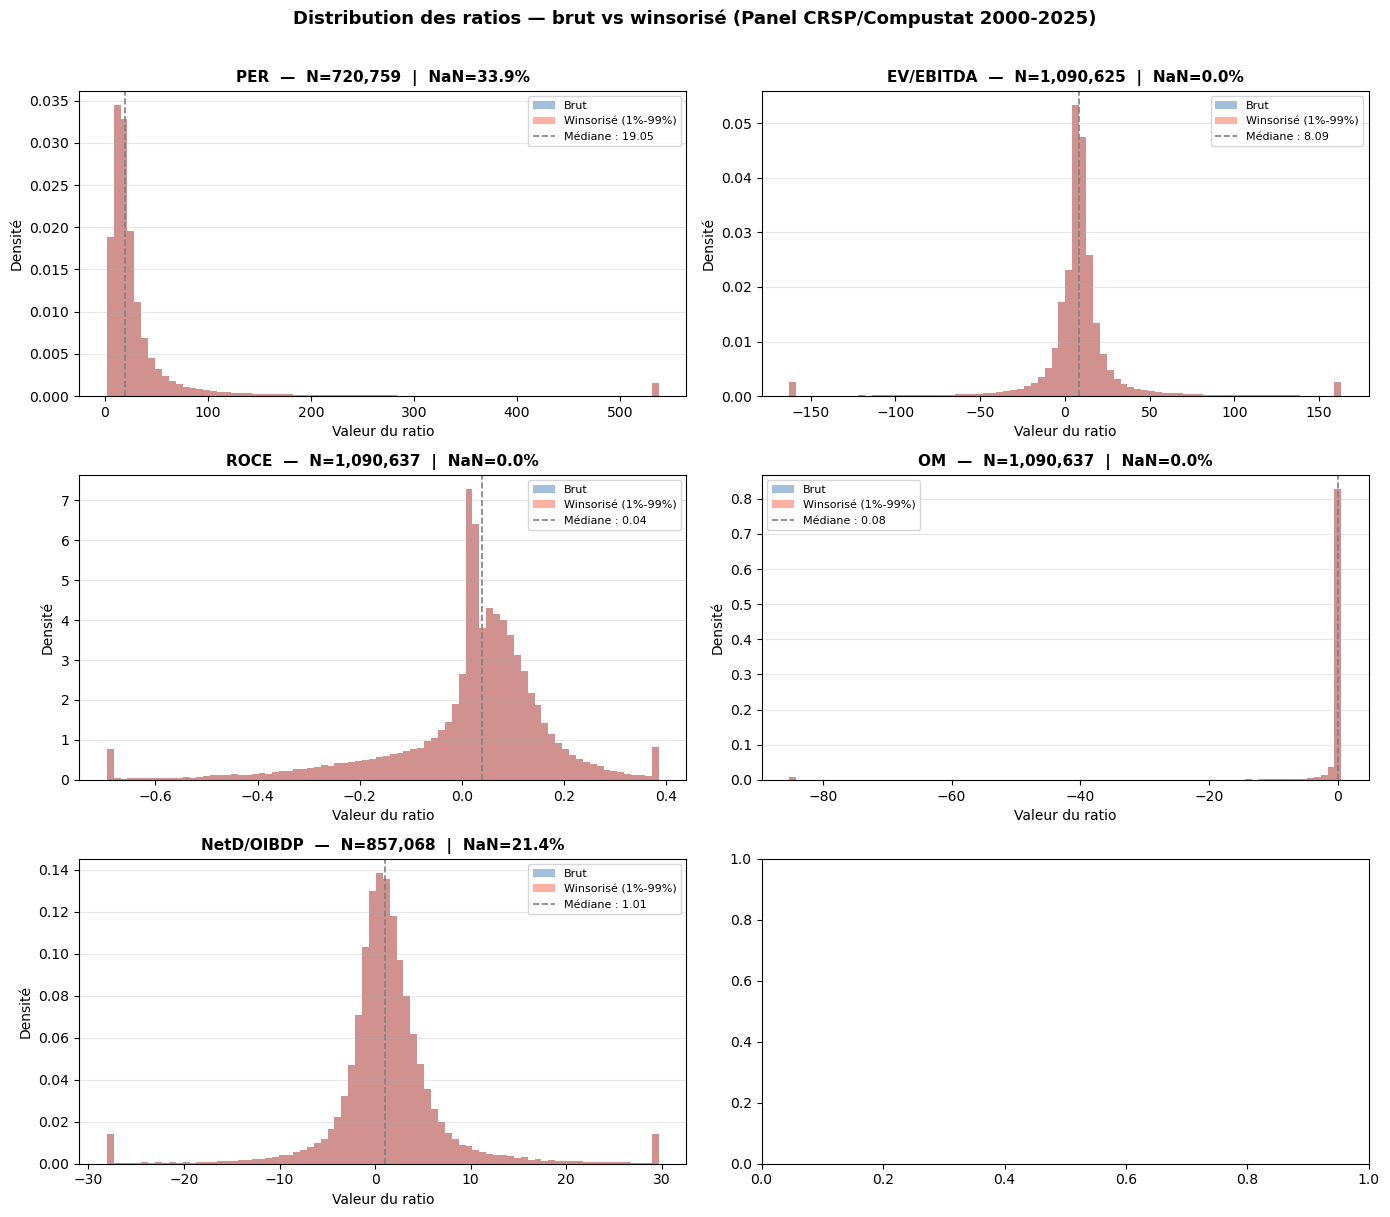

In [34]:
# Distribution des ratios pour l'univers complet

ratios = ['PER', 'EV/EBITDA', 'ROCE', 'OM', 'NetD/OIBDP']

# Winsorisation 1%-99%
panel_plot = panel.copy()
for r in ratios:
    q01 = panel[r].quantile(0.01)
    q99 = panel[r].quantile(0.99)
    panel_plot[f'{r}_wins'] = panel[r].clip(q01, q99)

# Stats descriptives
stats = {}
for r in ratios:
    col = panel[r].dropna()
    stats[r] = {
        'N'      : len(col),
        'Mean'   : round(col.mean(), 2),
        'Median' : round(col.median(), 2),
        'Std'    : round(col.std(), 2),
        'P1'     : round(col.quantile(0.01), 2),
        'P99'    : round(col.quantile(0.99), 2),
        'NaN%'   : round(panel[r].isna().mean() * 100, 1)
    }
df_stats = pd.DataFrame(stats).T
print(df_stats)

# Figure
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, r in enumerate(ratios):
    ax = axes[i]
    raw  = panel[r].dropna()
    wins = panel_plot[f'{r}_wins'].dropna()
    xmin, xmax = raw.quantile(0.01), raw.quantile(0.99)

    ax.hist(raw.clip(xmin, xmax), bins=80, color='steelblue',
            alpha=0.5, label='Brut', density=True)
    ax.hist(wins, bins=80, color='tomato',
            alpha=0.5, label='Winsorisé (1%-99%)', density=True)
    ax.axvline(raw.median(), color='gray', linestyle='--', linewidth=1.2,
               label=f'Médiane : {raw.median():.2f}')

    ax.set_title(f'{r}  —  N={len(raw):,}  |  NaN={panel[r].isna().mean()*100:.1f}%',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeur du ratio')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribution des ratios — brut vs winsorisé (Panel CRSP/Compustat 2000-2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Selection de l'univers :

In [35]:
# Small/Mid caps : Market Cap > 300 M$ et < 10000 M$

panel_sm = panel[(panel['Market Cap'] >= 300) & (panel['Market Cap'] < 10000)]
panel_sm['permno'].nunique()

6264

                   N   Mean  Median      Std      P1     P5    P25    P75     P95     P99  NaN%
PER         393060.0  67.62   20.24  1000.92    2.65   6.07  13.42  33.28  117.56  545.98  24.1
EV/EBITDA   517946.0   8.42    9.48  1611.86 -177.56 -24.17   5.74  14.78   42.75  168.71   0.0
ROCE        517958.0   0.06    0.07     0.33   -0.39  -0.16   0.02   0.12    0.24    0.41   0.0
OM          517958.0  -9.53    0.10   342.42  -22.24  -0.86   0.04   0.19    0.45    0.60   0.0
NetD/OIBDP  456605.0   1.05    0.99    97.54  -20.04  -5.18  -0.76   3.05    8.07   21.41  11.8


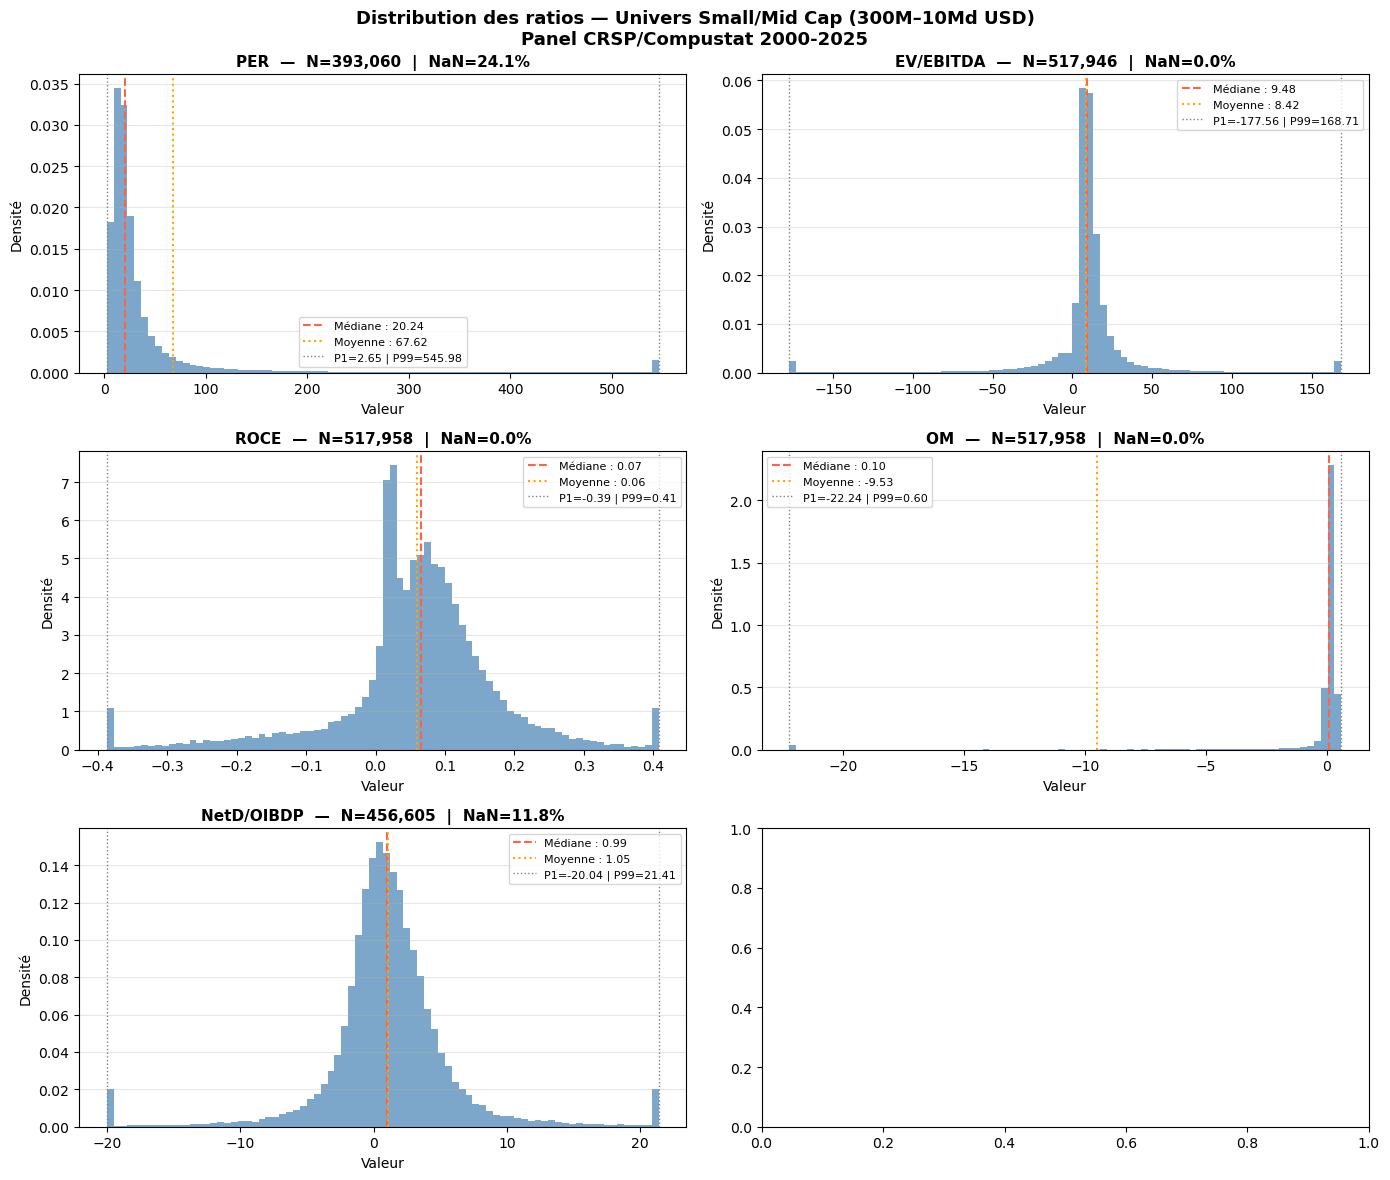

In [36]:
# Distribution des ratios pour l'univers Small/Mid CAP

# Stats descriptives sur l'univers small/mid 

stats = {}
for r in ratios:
    col = panel_sm[r].dropna()
    stats[r] = {
        'N'      : len(col),
        'Mean'   : round(col.mean(), 2),
        'Median' : round(col.median(), 2),
        'Std'    : round(col.std(), 2),
        'P1'     : round(col.quantile(0.01), 2),
        'P5'     : round(col.quantile(0.05), 2),
        'P25'    : round(col.quantile(0.25), 2),
        'P75'    : round(col.quantile(0.75), 2),
        'P95'    : round(col.quantile(0.95), 2),
        'P99'    : round(col.quantile(0.99), 2),
        'NaN%'   : round(panel_sm[r].isna().mean() * 100, 1)
    }

df_stats = pd.DataFrame(stats).T
print(df_stats.to_string())

# Figure
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, r in enumerate(ratios):
    ax = axes[i]
    col = panel_sm[r].dropna()
    
    # Borne d'affichage P1-P99
    xmin = col.quantile(0.01)
    xmax = col.quantile(0.99)
    col_clipped = col.clip(xmin, xmax)

    ax.hist(col_clipped, bins=80, color='steelblue', alpha=0.7, density=True)
    ax.axvline(col.median(), color='tomato',  linestyle='--', linewidth=1.5,
               label=f'Médiane : {col.median():.2f}')
    ax.axvline(col.mean(),   color='orange',  linestyle=':',  linewidth=1.5,
               label=f'Moyenne : {col.mean():.2f}')
    ax.axvline(xmin, color='gray', linestyle=':', linewidth=1,
               label=f'P1={xmin:.2f} | P99={xmax:.2f}')
    ax.axvline(xmax, color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f'{r}  —  N={len(col):,}  |  NaN={panel_sm[r].isna().mean()*100:.1f}%',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Distribution des ratios — Univers Small/Mid Cap (300M–10Md USD)\nPanel CRSP/Compustat 2000-2025',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [37]:
# Diagnostique
for r in ratios:
    col = panel_sm[r].dropna()
    p01, p99 = col.quantile(0.01), col.quantile(0.99)
    extreme_high = (col > p99).sum()
    extreme_low  = (col < p01).sum()
    print(f"\n{r}")
    print(f"  P1={p01:.2f} | P99={p99:.2f} | Std={col.std():.2f}")
    print(f"  Obs > P99 : {extreme_high:,} ({extreme_high/len(col)*100:.1f}%)")
    print(f"  Obs < P1  : {extreme_low:,}  ({extreme_low/len(col)*100:.1f}%)")


PER
  P1=2.65 | P99=545.98 | Std=1000.92
  Obs > P99 : 3,931 (1.0%)
  Obs < P1  : 3,931  (1.0%)

EV/EBITDA
  P1=-177.56 | P99=168.71 | Std=1611.86
  Obs > P99 : 5,180 (1.0%)
  Obs < P1  : 5,180  (1.0%)

ROCE
  P1=-0.39 | P99=0.41 | Std=0.33
  Obs > P99 : 5,176 (1.0%)
  Obs < P1  : 5,171  (1.0%)

OM
  P1=-22.24 | P99=0.60 | Std=342.42
  Obs > P99 : 5,172 (1.0%)
  Obs < P1  : 5,175  (1.0%)

NetD/OIBDP
  P1=-20.04 | P99=21.41 | Std=97.54
  Obs > P99 : 4,567 (1.0%)
  Obs < P1  : 4,566  (1.0%)


In [39]:
#Au vu des standard deviation, il faut traiter des outlayers

# PER : une valeur > 500 n'est pas investissable
panel_sm.loc[panel_sm['PER'] > 500, 'PER'] = np.nan

# EV/EBITDA : > 100 = non investissable 
panel_sm.loc[panel_sm['EV/EBITDA'] > 100, 'EV/EBITDA'] = np.nan

# OM : marge > 100% ou < -100% = erreur de données
panel_sm.loc[panel_sm['OM'] >  1.0, 'OM'] = np.nan
panel_sm.loc[panel_sm['OM'] < -1.0, 'OM'] = np.nan

# ROE : > 5 (500%) ou < -5 (-500%) = quasi certainement une erreur
#panel_sm.loc[panel_sm['ROE'] >  5, 'ROE'] = np.nan
#panel_sm.loc[panel_sm['ROE'] < -5, 'ROE'] = np.nan

# NetD/OIBDP : levier > 30 ou < -30 = non interprétable
panel_sm.loc[panel_sm['NetD/OIBDP'] >  30, 'NetD/OIBDP'] = np.nan
panel_sm.loc[panel_sm['NetD/OIBDP'] < -30, 'NetD/OIBDP'] = np.nan


                   N   Mean  Median      Std      P1     P5    P25    P75    P95     P99  NaN%
PER         388755.0  32.63   20.06    45.53    2.64   6.04  13.35  32.55  99.87  258.52  24.9
EV/EBITDA   508592.0  -5.52    9.35  1108.32 -180.97 -24.84   5.65  14.34  34.16   68.63   1.8
ROCE        517958.0   0.06    0.07     0.33   -0.39  -0.16   0.02   0.12   0.24    0.41   0.0
OM          493514.0   0.12    0.10     0.20   -0.63  -0.16   0.05   0.20   0.46    0.60   4.7
NetD/OIBDP  450982.0   1.18    0.99     4.55  -13.03  -4.74  -0.74   3.02   7.60   16.05  12.9


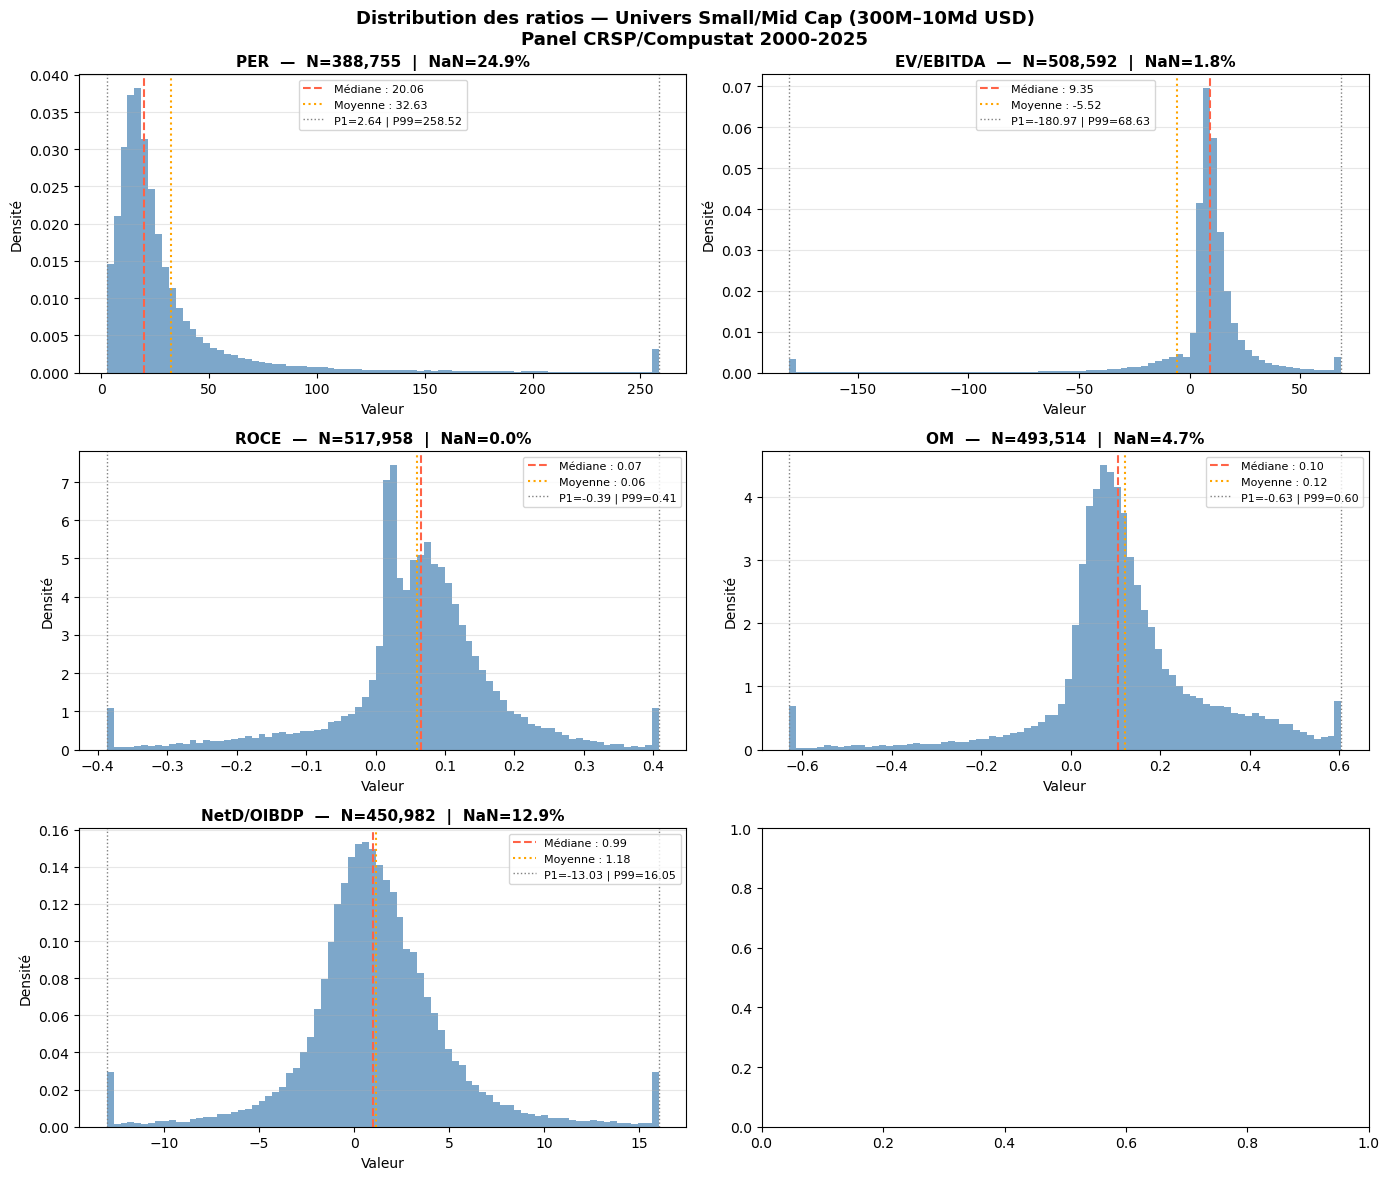

In [40]:
# Distribution des ratios pour l'univers Small/Mid CAP

# Stats descriptives sur l'univers small/mid 

stats = {}
for r in ratios:
    col = panel_sm[r].dropna()
    stats[r] = {
        'N'      : len(col),
        'Mean'   : round(col.mean(), 2),
        'Median' : round(col.median(), 2),
        'Std'    : round(col.std(), 2),
        'P1'     : round(col.quantile(0.01), 2),
        'P5'     : round(col.quantile(0.05), 2),
        'P25'    : round(col.quantile(0.25), 2),
        'P75'    : round(col.quantile(0.75), 2),
        'P95'    : round(col.quantile(0.95), 2),
        'P99'    : round(col.quantile(0.99), 2),
        'NaN%'   : round(panel_sm[r].isna().mean() * 100, 1)
    }

df_stats = pd.DataFrame(stats).T
print(df_stats.to_string())

# Figure
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, r in enumerate(ratios):
    ax = axes[i]
    col = panel_sm[r].dropna()
    
    # Borne d'affichage P1-P99
    xmin = col.quantile(0.01)
    xmax = col.quantile(0.99)
    col_clipped = col.clip(xmin, xmax)

    ax.hist(col_clipped, bins=80, color='steelblue', alpha=0.7, density=True)
    ax.axvline(col.median(), color='tomato',  linestyle='--', linewidth=1.5,
               label=f'Médiane : {col.median():.2f}')
    ax.axvline(col.mean(),   color='orange',  linestyle=':',  linewidth=1.5,
               label=f'Moyenne : {col.mean():.2f}')
    ax.axvline(xmin, color='gray', linestyle=':', linewidth=1,
               label=f'P1={xmin:.2f} | P99={xmax:.2f}')
    ax.axvline(xmax, color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f'{r}  —  N={len(col):,}  |  NaN={panel_sm[r].isna().mean()*100:.1f}%',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Distribution des ratios — Univers Small/Mid Cap (300M–10Md USD)\nPanel CRSP/Compustat 2000-2025',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [41]:
# Diagnostique
for r in ratios:
    col = panel_sm[r].dropna()
    p01, p99 = col.quantile(0.01), col.quantile(0.99)
    extreme_high = (col > p99).sum()
    extreme_low  = (col < p01).sum()
    print(f"\n{r}")
    print(f"  P1={p01:.2f} | P99={p99:.2f} | Std={col.std():.2f}")
    print(f"  Obs > P99 : {extreme_high:,} ({extreme_high/len(col)*100:.1f}%)")
    print(f"  Obs < P1  : {extreme_low:,}  ({extreme_low/len(col)*100:.1f}%)")


PER
  P1=2.64 | P99=258.52 | Std=45.53
  Obs > P99 : 3,888 (1.0%)
  Obs < P1  : 3,888  (1.0%)

EV/EBITDA
  P1=-180.97 | P99=68.63 | Std=1108.32
  Obs > P99 : 5,086 (1.0%)
  Obs < P1  : 5,086  (1.0%)

ROCE
  P1=-0.39 | P99=0.41 | Std=0.33
  Obs > P99 : 5,176 (1.0%)
  Obs < P1  : 5,171  (1.0%)

OM
  P1=-0.63 | P99=0.60 | Std=0.20
  Obs > P99 : 4,929 (1.0%)
  Obs < P1  : 4,936  (1.0%)

NetD/OIBDP
  P1=-13.03 | P99=16.05 | Std=4.55
  Obs > P99 : 4,503 (1.0%)
  Obs < P1  : 4,510  (1.0%)


In [50]:
# Univers value

value_mask = (
    (panel_sm['PER']      < 15) &
    (panel_sm['EV/EBITDA'] < 10) #&
    #(panel_sm['PER']      > 0)  #&
    #(panel_sm['EV/EBITDA'] > 0)
)
value = panel_sm[value_mask].copy()


Ajout du momentum :

In [43]:
# Momentum 6M 
panel_sm['mom_6m'] = (
    panel_sm.groupby('permno')['ret']
    .transform(lambda x: (1 + x.shift(1)).rolling(5).apply(np.prod, raw=True) - 1)
)

# Fusionner mom_6m dans l'univers value
value  = value.merge(panel_sm[['permno','date','mom_6m']], on=['permno','date'], how='left')

# Filtre momentum : momentum > médiane de l'univers value à cette date
mom_med = value.groupby('date')['mom_6m'].transform('median')
value['mom_ok'] = value['mom_6m'] >= mom_med


/tmp/ipykernel_4286/2804836076.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel_sm['mom_6m'] = (


Construction des portfolios :

In [51]:
# Score qualité

# Score élevé = bonne qualité : long
# Score faible = mauvaise qualité : short

for col, asc in [('ROCE', True),
                ('NetD/OIBDP', False)]:#,        # plus haut = mieux
                 #('ROE',  True),        # plus haut = mieux
                 #('OM',   True),        # plus haut = mieux
                   # plus bas  = mieux
        value[f'rank_{col[:2]}'] = value.groupby('date')[col].rank(pct=True, ascending=asc)

quality_cols = ['rank_ROCE', 'rank_NetD']#, 'rank_ROE', 'rank_OM', 'rank_NetD']
value['n_quality'] = value[quality_cols].notna().sum(axis=1)
value['score']     = value[quality_cols].mean(axis=1)  # skipna=True

# Panel filtré : min 2 ratios qualité disponibles

panel_filtered = value#[value['n_quality'] >= 2].copy()
value.sort_values('score', ascending = False)
################panel_filtered = value['permno'].unique.iloc[-60:,:] 

# Paramètres portefeuille 
n_long       = 30
n_short      = 30
max_replace  = 5
hard_stop    = 60
score_buffer = 0.05

print(f"Titres uniques : {panel_filtered['permno'].nunique()}")


KeyError: "None of [Index(['rank_ROCE', 'rank_NetD'], dtype='object')] are in the [columns]"

In [52]:
# Score qualité
# Score élevé = bonne qualité : long
# Score faible = mauvaise qualité : short

for col, asc in [('ROCE', True),          # ← virgule manquante après True) + fermeture de liste corrigée
                 ('NetD/OIBDP', False)]:   # ← le # était mal placé, coupait la liste
                                           # plus bas = mieux
    value[f'rank_{col[:4]}'] = value.groupby('date')[col].rank(pct=True, ascending=asc)
    # ← [:1] remplacé par [:4] pour obtenir rank_ROCE et rank_NetD (au lieu de rank_R et rank_N)

quality_cols = ['rank_ROCE', 'rank_NetD']
value['n_quality'] = value[quality_cols].notna().sum(axis=1)
value['score']     = value[quality_cols].mean(axis=1)

# Panel filtré : min 2 ratios qualité disponibles
panel_filtered = value
value = value.sort_values('score', ascending=False)  # ← résultat réassigné à value


# Paramètres portefeuille 
n_long       = 30
n_short      = 30
max_replace  = 5
hard_stop    = 60
score_buffer = 0.05

print(f"Titres uniques : {panel_filtered['permno'].nunique()}")


Titres uniques : 3211


In [69]:
# Score qualité

# Score élevé = bonne qualité : long
# Score faible = mauvaise qualité : short

# On ne garde que ROCE
for col, asc in [('ROCE', True)]:  # plus haut = mieux
    value[f'rank_{col}'] = value.groupby('date')[col].rank(pct=True, ascending=asc)

# Colonnes de qualité : uniquement ROCE
quality_cols = ['rank_ROCE']

# Nombre de ratios qualité dispo (ici 1 max)
value['n_quality'] = value[quality_cols].notna().sum(axis=1)

# Score moyen qualité (ici identique à rank_ROCE)
value['score'] = value[quality_cols].mean(axis=1)

# Panel filtré : si tu veux vraiment “ROCE seulement”, tu peux mettre >=1
panel_filtered = value[value['n_quality'] >= 1].copy()

# Paramètres portefeuille 
n_long       = 30
n_short      = 30
max_replace  = 5
hard_stop    = 60
score_buffer = 0.05

print(f"Titres uniques : {panel_filtered['permno'].nunique()}")


Titres uniques : 3128


In [53]:
# Dates de rebalancement
rebal_dates = (panel_filtered[panel_filtered['date'].dt.month.isin([6, 12])]
            .groupby(pd.Grouper(key='date', freq='6ME'))['date']
            .max().dropna())

rebal_dates = [d for d in rebal_dates if d >= pd.Timestamp('2001-12-31')]

# Univers d'entreprises vivantes par date via panel_sm (pour les delisting)
alive_by_date = panel_sm.groupby('date')['permno'].apply(set).to_dict()

# Momentum médian par date (filtre d'entrée long)
mom_by_date = (panel_sm.groupby('date')
               .apply(lambda x: set(x.loc[x['mom_6m'] >= x['mom_6m'].median(), 'permno']),
                      include_groups=False)
               .to_dict())

long_snapshots = {}
short_snapshots = {}
long_pf = set()
short_pf = set()


permno_to_name = (
    panel_filtered.dropna(subset=['conm'])
    .sort_values('date')
    .groupby('permno')['conm']
    .last()
    .to_dict()
)

for i, d in enumerate(rebal_dates):

    rank = (panel_filtered[panel_filtered['date'] == d]
            .sort_values('n_quality', ascending = False)
            #.iloc[-90:, :]###########################################################################################################################
            .set_index('permno')['n_quality']
            .dropna())

    ranked_desc = rank.sort_values(ascending=False)  # haut score → LONG
    ranked_asc = rank.sort_values(ascending=True)   # bas score  → SHORT
    mom_ok = mom_by_date.get(d, set())
    universe_alive = alive_by_date.get(d, set())
    in_value_at_d = set(rank.index)                   # titres dans l'univers value à cette date

    # Premier rebalancement
    if i == 0:
        cands_long = [p for p in ranked_desc.index if p in mom_ok]
        long_pf = set(cands_long[:n_long])
        short_pf = set(ranked_asc.head(n_short).index)

    else:

        # Long : logique de rebalancement patient

        #Hard stop qualité : sortie forcée si hors top hard_stop
        #    (uniquement pour les titres encore dans l'univers value)
        #top_hard = set(ranked_desc.head(hard_stop).index)
        #long_pf -= (long_pf & in_value_at_d) - top_hard

        # Parmi les restants : identifier les max_replace pires qualités
        in_long   = rank[rank.index.isin(long_pf)].sort_values(ascending=True)
        cands_out = list(in_long.head(max_replace).index)

        # Meilleurs prétendants non détenus : univers value + momentum ok
        cands_in  = [p for p in ranked_desc.index
                     if p not in long_pf and p in mom_ok][:max_replace]

        # Remplacement avec buffer : trade seulement si gain de qualité > score_buffer
        score_floor = float(in_long.iloc[0]) if len(in_long) > 0 else 0
        for out, new in zip(cands_out, cands_in):
            if float(rank.get(new, 0)) > score_floor + score_buffer:
                long_pf.discard(out)
                long_pf.add(new)

        # Short : logique miroir

        # Hard stop qualité : sortie forcée si hors bottom hard_stop
        #bottom_hard = set(ranked_asc.head(hard_stop).index)
        #short_pf   -= (short_pf & in_value_at_d) - bottom_hard

        # Parmi les restants : identifier les max_replace moins mauvais qualités
        in_short    = rank[rank.index.isin(short_pf)].sort_values(ascending=False)
        cands_out_s = list(in_short.head(max_replace).index)

        # Pires prétendants non détenus (pas de filtre momentum sur le short)
        cands_in_s  = [p for p in ranked_asc.index
                       if p not in short_pf][:max_replace]

        # Remplacement avec buffer
        score_ceil = float(in_short.iloc[0]) if len(in_short) > 0 else 1
        for out, new in zip(cands_out_s, cands_in_s):
            if float(rank.get(new, 1)) < score_ceil - score_buffer:
                short_pf.discard(out)
                short_pf.add(new)

        # Gestion des événements corporate : delisting, fusion
        # Sortie uniquement si le titre n'est plus coté dans panel_sm
        long_pf  &= universe_alive
        short_pf &= universe_alive

        # Remplissage jusqu'à la taille cible
        # Compense les sorties non couvertes par le buffer (delisting, hard stop)
        if len(long_pf) < n_long:
            fill   = [p for p in ranked_desc.index
                      if p not in long_pf and p in mom_ok]
            long_pf.update(fill[:n_long - len(long_pf)])

        if len(short_pf) < n_short:
            fill_s = [p for p in ranked_asc.index if p not in short_pf]
            short_pf.update(fill_s[:n_short - len(short_pf)])

    long_snapshots[d]  = set(long_pf)
    short_snapshots[d] = set(short_pf)


# Collecte des scores sur toutes les dates de rebalancement (à supprimer)
scores_long_all  = []
scores_short_all = []

for d in sorted(long_snapshots.keys()):
    scores_l = panel_filtered[
        (panel_filtered['date'] == d) &
        (panel_filtered['permno'].isin(long_snapshots[d]))
    ]['n_quality'].dropna().tolist()

    scores_s = panel_filtered[
        (panel_filtered['date'] == d) &
        (panel_filtered['permno'].isin(short_snapshots[d]))
    ]['n_quality'].dropna().tolist()

    scores_long_all.extend(scores_l)
    scores_short_all.extend(scores_s)
########################################################################

# Vérification enrichie
def fmt_pf(pf_set, mapping):
    return sorted(f"{p} ({mapping.get(p, 'N/A')})" for p in pf_set)

for d in sorted(long_snapshots.keys()):
    n_dispo = panel_filtered[panel_filtered['date'] == d]['permno'].nunique()
    long_names  = fmt_pf(long_snapshots[d],  permno_to_name)
    short_names = fmt_pf(short_snapshots[d], permno_to_name)

    print(f"\n{'='*60}")
    print(f"{str(d)[:10]}  |  Univers : {n_dispo:>4}  |  LONG : {len(long_snapshots[d]):>3}  |  SHORT : {len(short_snapshots[d]):>3}")
    print(f"  LONG  : {', '.join(long_names)}")
    print(f"  SHORT : {', '.join(short_names)}")



2001-12-31  |  Univers :  444  |  LONG :  30  |  SHORT :  30
  LONG  : 11404 (CONSOLIDATED EDISON INC), 11406 (CNA SURETY CORP), 11478 (BERRY CORP), 15077 (UST INC), 16890 (BANTA CORP), 24010 (ENTERGY CORP), 42534 (JOHNSON CONTROLS INTL PLC), 45655 (CDI CORP), 48523 (MARZETTI CO (THE)), 49905 (KATE SPADE & CO), 53663 (UIL HOLDINGS CORP), 60580 (TORO CO), 65656 (LAFARGE NORTH AMERICA INC), 66050 (KID BRANDS INC), 66114 (TEMPLE-INLAND INC), 75900 (AZTAR CORP), 76282 (AUTONATION INC), 76573 (MUELLER INDUSTRIES), 76722 (STATE AUTO FINANCIAL CORP), 76779 (OXFORD HEALTH PLANS INC), 77081 (YORK INTERNATIONAL CORP), 83455 (PATINA OIL & GAS CORP), 83720 (FBL FINANCIAL GROUP INC-CL A), 83916 (TTEC HOLDINGS INC), 84656 (AUTOLIV INC), 85344 (SECURITY CAP GRP INC  -CL B), 85349 (MERITOR INC), 86809 (STANCORP FINANCIAL GROUP INC), 88235 (PURE RESOURCES INC), 90879 (PACIFICARE HEALTH SYSTEMS)
  SHORT : 12008 (DYCOM INDUSTRIES INC), 18016 (HERCULES INC), 19828 (WENDY'S CO), 25232 (ONEOK INC), 41487 (

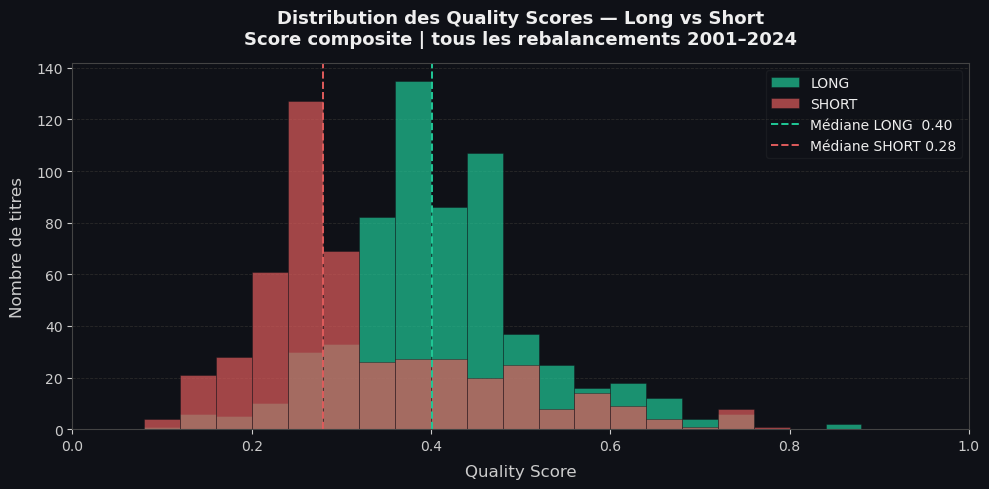

In [52]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#0f1117',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#ccc',
    'ytick.color':      '#ccc',
    'text.color':       '#eee',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
})

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 26)

ax.hist(scores_long_all,  bins=bins, alpha=0.70, color='#20c997',
        label='LONG',  edgecolor='#0f1117', linewidth=0.4)
ax.hist(scores_short_all, bins=bins, alpha=0.70, color='#e05c5c',
        label='SHORT', edgecolor='#0f1117', linewidth=0.4)

ax.axvline(np.median(scores_long_all),  color='#20c997', linestyle='--',
           linewidth=1.4, label=f'Médiane LONG  {np.median(scores_long_all):.2f}')
ax.axvline(np.median(scores_short_all), color='#e05c5c', linestyle='--',
           linewidth=1.4, label=f'Médiane SHORT {np.median(scores_short_all):.2f}')

ax.set_xlabel('Quality Score', fontsize=12, labelpad=8)
ax.set_ylabel('Nombre de titres', fontsize=12, labelpad=8)
ax.set_title(
    'Distribution des Quality Scores — Long vs Short\n'
    'Score composite | tous les rebalancements 2001–2024',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlim(0, 1)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(framealpha=0.15, edgecolor='#555', fontsize=10)

plt.tight_layout()
plt.savefig('quality_score_hist.png', dpi=150, bbox_inches='tight')
plt.show()


In [56]:
panel_sm.drop(columns=['ret_next','active_rebal_x', 'position','active_rebal_y'], inplace=True)

In [57]:
# Return futur (t+1) calculé sur panel_sm complet (tous les mois présents)
panel_sm = panel_sm.sort_values(['permno', 'date'])
panel_sm['ret_next'] = panel_sm.groupby('permno')['ret'].shift(-1)

# Tagging long / short sur panel_sm (capture tous les mois détenus,
# y compris les mois où le titre est sorti du filtre value)
panel_sm = pd.merge_asof(
    panel_sm.sort_values('date'),
    pd.DataFrame({'active_rebal': sorted(long_snapshots.keys())}),
    left_on='date', right_on='active_rebal', direction='backward'
)

panel_sm['position'] = 'NEUTRAL'

for rebal_date, longs in long_snapshots.items():
    mask_long = (panel_sm['active_rebal'] == rebal_date) & \
                (panel_sm['permno'].isin(longs))
    panel_sm.loc[mask_long, 'position'] = 'LONG'

for rebal_date, shorts in short_snapshots.items():
    mask_short = (panel_sm['active_rebal'] == rebal_date) & \
                 (panel_sm['permno'].isin(shorts))
    panel_sm.loc[mask_short, 'position'] = 'SHORT'

# Returns long / short par date
perf_long  = (panel_sm[panel_sm['position'] == 'LONG']
              .dropna(subset=['ret_next'])
              .query('ret_next <= 1.0 and ret_next >= -1.0')
              .groupby('date')['ret_next'].mean()
              .rename('LONG'))

perf_short = (panel_sm[panel_sm['position'] == 'SHORT']
              .dropna(subset=['ret_next'])
              .query('ret_next <= 1.0 and ret_next >= -1.0')
              .groupby('date')['ret_next'].mean()
              .rename('SHORT'))

# Benchmark : univers small/mid équipondéré
benchmark = (panel_sm
             .dropna(subset=['ret_next'])
             .query('ret_next <= 1.0 and ret_next >= -1.0')
             .groupby('date')['ret_next'].mean()
             .rename('Benchmark'))

# Assemblage
perf = pd.concat([perf_long, perf_short, benchmark], axis=1).dropna()
perf['LS'] = perf['LONG'] - perf['SHORT']

# Performance annualisée
print("=" * 55)
print(f"{'Série':<15} {'Ret ann.':>10} {'Vol ann.':>10} {'Sharpe':>10}")
print("=" * 55)
for col in ['LONG', 'SHORT', 'LS', 'Benchmark']:
    mu     = perf[col].mean() * 12
    sigma  = perf[col].std() * np.sqrt(12)
    sharpe = mu / sigma
    print(f"{col:<15} {mu:>10.2%} {sigma:>10.2%} {sharpe:>10.2f}")

# Diagnostic : taille moyenne des portefeuilles
avg_long_size  = np.mean([len(v) for v in long_snapshots.values()])
avg_short_size = np.mean([len(v) for v in short_snapshots.values()])
print(f"\nTaille moy. LONG  : {avg_long_size:.1f} titres")
print(f"Taille moy. SHORT : {avg_short_size:.1f} titres")


/tmp/ipykernel_4286/3689219327.py:28: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query('ret_next <= 1.0 and ret_next >= -1.0')
/tmp/ipykernel_4286/3689219327.py:34: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query('ret_next <= 1.0 and ret_next >= -1.0')


Série             Ret ann.   Vol ann.     Sharpe
LONG                15.56%     18.48%       0.84
SHORT               18.33%     21.72%       0.84
LS                  -2.77%     11.08%      -0.25
Benchmark           17.96%     18.20%       0.99

Taille moy. LONG  : 30.0 titres
Taille moy. SHORT : 30.0 titres


/tmp/ipykernel_4286/3689219327.py:41: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query('ret_next <= 1.0 and ret_next >= -1.0')


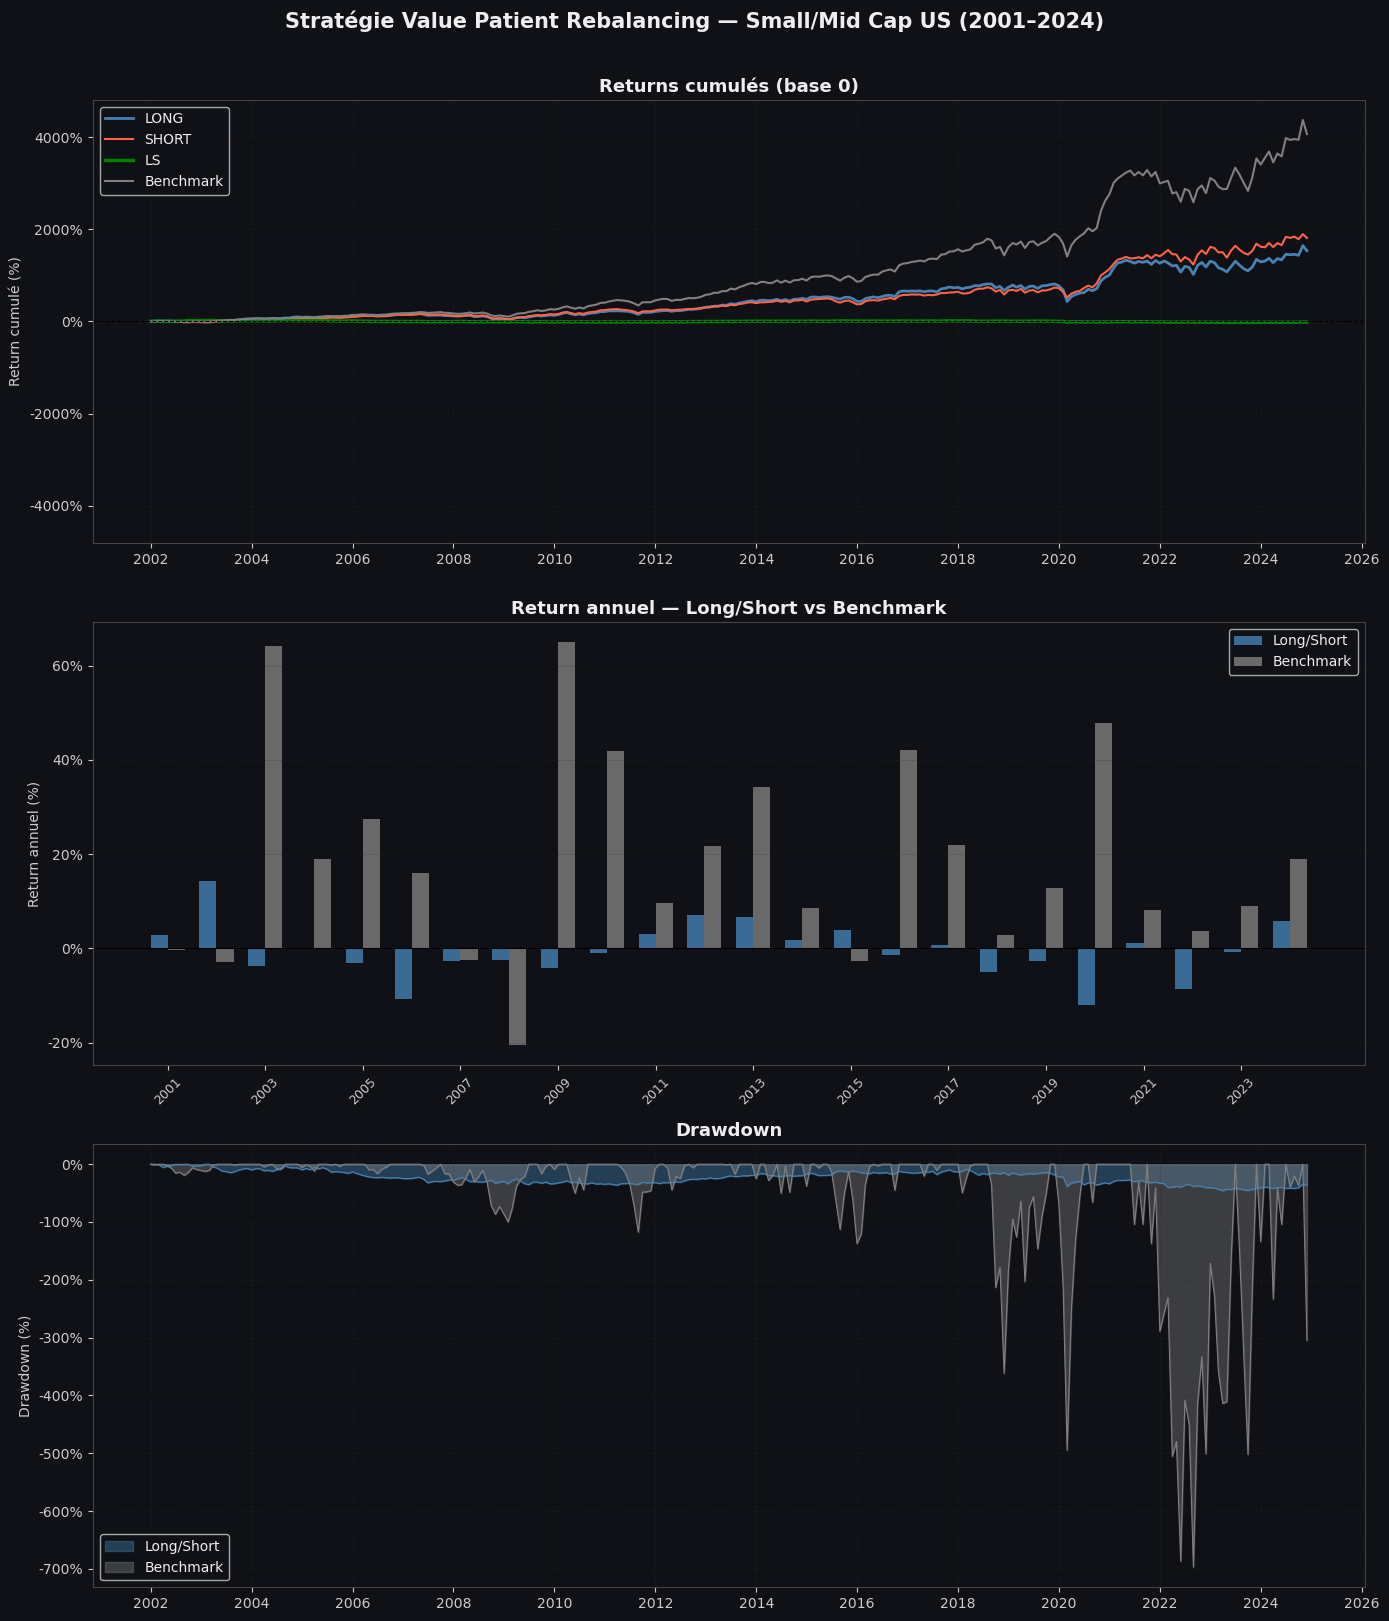

In [56]:
# Returns cumulés
cum = (1 + perf[['LONG', 'SHORT', 'LS', 'Benchmark']].fillna(0)).cumprod() - 1

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Graphique 1 : Returns cumulés
ax = axes[0]
for col, color, lw in [('LONG',      'steelblue', 2),
                        ('SHORT',     'tomato',    1.5),
                        ('LS',        'green',     2.5),
                        ('Benchmark', 'gray',      1.5)]:
    ax.plot(cum.index, cum[col] * 100, label=col, color=color, linewidth=lw)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
yabs = max(abs(np.nanmin(cum.values)), abs(np.nanmax(cum.values))) * 100 * 1.1
ax.set_ylim(-yabs, yabs)
ax.set_title('Returns cumulés (base 0)', fontsize=13, fontweight='bold')
ax.set_ylabel('Return cumulé (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Graphique 2 : Return annuel L/S vs Benchmark
ax = axes[1]
annual = perf[['LS', 'Benchmark']].resample('YE').apply(
    lambda x: (1 + x).prod() - 1
)
x = np.arange(len(annual))
w = 0.35
ax.bar(x - w/2, annual['LS']        * 100, width=w, label='Long/Short', color='steelblue', alpha=0.8)
ax.bar(x + w/2, annual['Benchmark'] * 100, width=w, label='Benchmark',  color='gray',      alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x[::2])
ax.set_xticklabels([str(d.year) for d in annual.index[::2]], rotation=45, fontsize=9)
ax.set_title('Return annuel — Long/Short vs Benchmark', fontsize=13, fontweight='bold')
ax.set_ylabel('Return annuel (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Graphique 3 : Drawdown
ax = axes[2]
for col, color, label in [('LS',        'steelblue', 'Long/Short'),
                           ('Benchmark', 'gray',      'Benchmark')]:
    rolling_max = cum[col].cummax()
    drawdown    = (cum[col] - rolling_max) * 100
    ax.fill_between(cum.index, drawdown, 0, alpha=0.4, color=color, label=label)
    ax.plot(cum.index, drawdown, color=color, linewidth=0.8)

ax.set_title('Drawdown', fontsize=13, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle(
    'Stratégie Value Patient Rebalancing — Small/Mid Cap US (2001–2024)',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


Composition des portefeuilles — Patient Rebalancing :
            n_long  n_short  n_total  turnover_pct
date                                              
2001-12-31      30       30      444           NaN
2002-06-30      30       30      289      3.333333
2002-12-31      30       30      339      6.666667
2003-06-30      30       30      298      3.333333
2003-12-31      30       30      198      3.333333
2004-06-30      30       30      251      3.333333
2004-12-31      30       30      201     10.000000
2005-06-30      30       30      299      6.666667
2005-12-31      30       30      308     10.000000
2006-06-30      30       30      359      3.333333
2006-12-31      30       30      314      0.000000
2007-06-30      30       30      377     10.000000
2007-12-31      30       30      511      3.333333
2008-06-30      30       30      584      6.666667
2008-12-31      30       30      778     13.333333
2009-06-30      30       30      610      3.333333
2009-12-31      30       30 

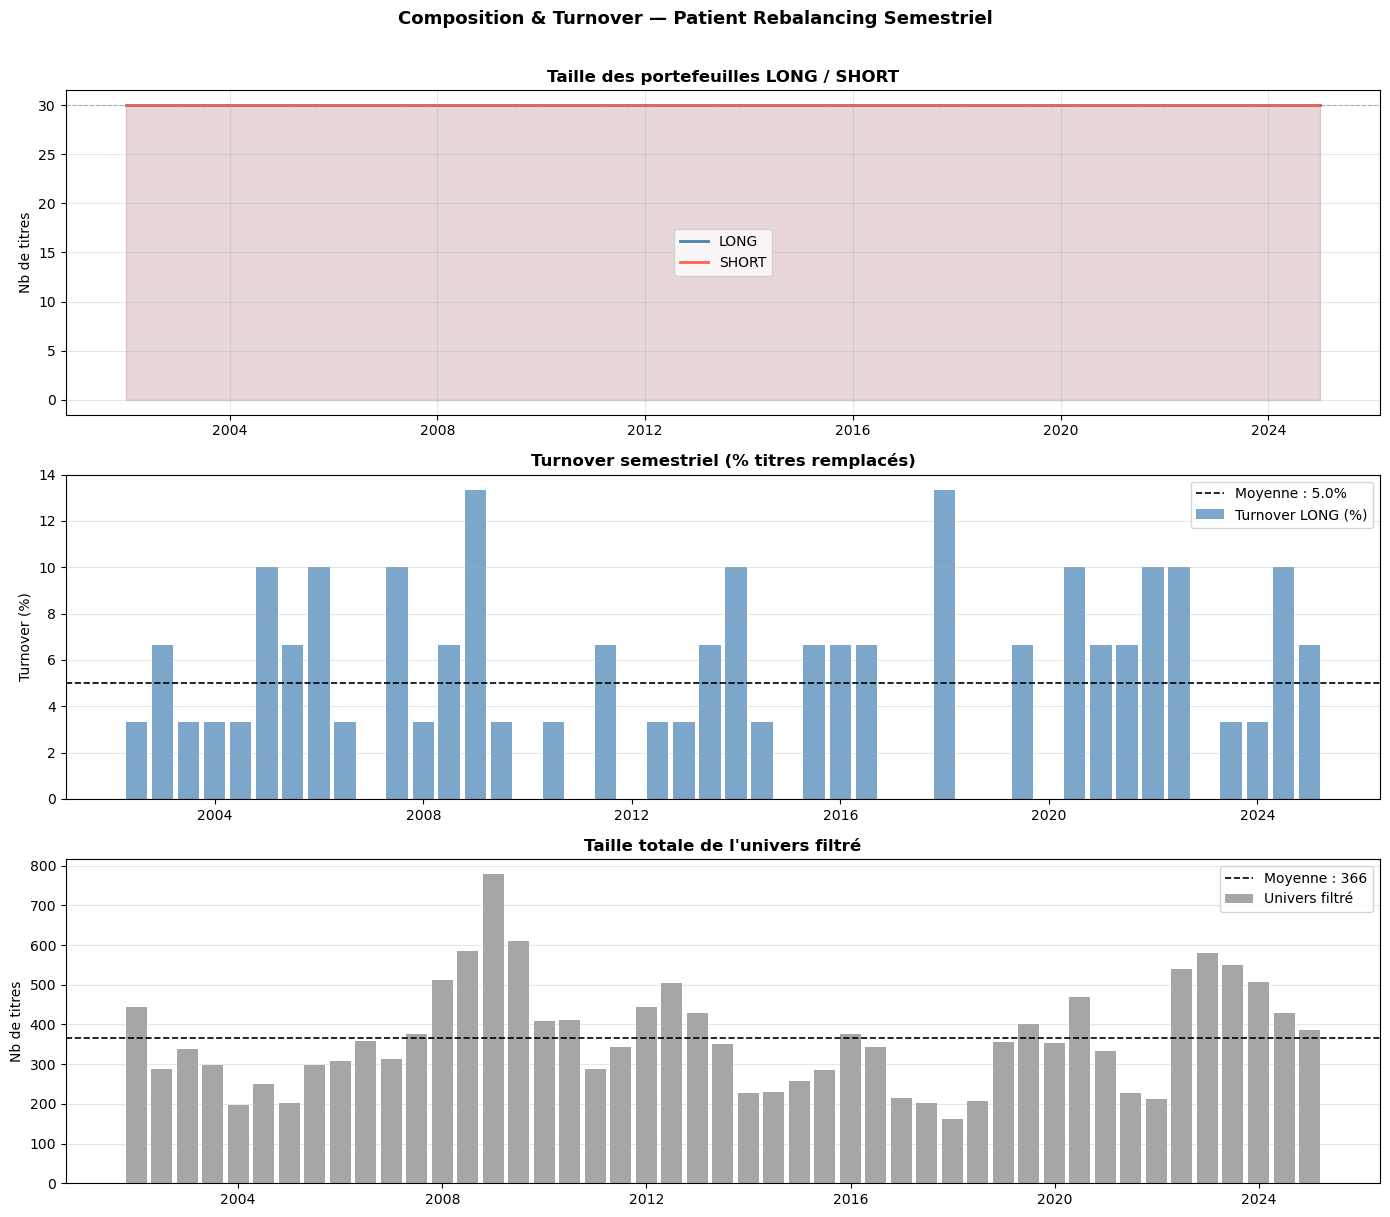

In [58]:
# Composition des portefeuilles à chaque rebalancement 
composition = []

for d in sorted(long_snapshots.keys()):
    composition.append({
        'date':    d,
        'n_long':  len(long_snapshots[d]),
        'n_short': len(short_snapshots[d]),
        'n_total': panel_filtered[panel_filtered['date'] == d]['permno'].nunique()
    })

df_comp = pd.DataFrame(composition).set_index('date')

# Turnover par rebalancement 
dates = sorted(long_snapshots.keys())
turnovers = [np.nan]  # pas de turnover au 1er rebal

for i in range(1, len(dates)):
    prev, curr = long_snapshots[dates[i-1]], long_snapshots[dates[i]]
    turnovers.append(len(prev - curr) / len(prev) * 100 if prev else np.nan)

df_comp['turnover_pct'] = turnovers

# Tableau synthétique 
print("Composition des portefeuilles — Patient Rebalancing :")
print("=" * 65)
print(df_comp.to_string())
print("=" * 65)
print(f"\nMoyenne LONG    : {df_comp['n_long'].mean():.0f} titres  (cible : {n_long})")
print(f"Moyenne SHORT   : {df_comp['n_short'].mean():.0f} titres  (cible : {n_short})")
print(f"Turnover moy.   : {df_comp['turnover_pct'].mean():.1f}% par semestre")
print(f"Turnover max    : {df_comp['turnover_pct'].max():.1f}%  "
      f"(date : {df_comp['turnover_pct'].idxmax().date()})")

# Graphique
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Graphique 1 : Taille LONG et SHORT
ax = axes[0]
ax.plot(df_comp.index, df_comp['n_long'],  color='steelblue', linewidth=2, label='LONG')
ax.plot(df_comp.index, df_comp['n_short'], color='tomato',    linewidth=2, label='SHORT')
ax.fill_between(df_comp.index, df_comp['n_long'],  alpha=0.15, color='steelblue')
ax.fill_between(df_comp.index, df_comp['n_short'], alpha=0.15, color='tomato')
ax.axhline(n_long, color='steelblue', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Taille des portefeuilles LONG / SHORT', fontsize=12, fontweight='bold')
ax.set_ylabel('Nb de titres')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Graphique 2 : Turnover semestriel
ax = axes[1]
ax.bar(df_comp.index, df_comp['turnover_pct'], width=150,
       color='steelblue', alpha=0.7, label='Turnover LONG (%)')
ax.axhline(df_comp['turnover_pct'].mean(), color='black', linestyle='--',
           linewidth=1.2, label=f"Moyenne : {df_comp['turnover_pct'].mean():.1f}%")
ax.set_title('Turnover semestriel (% titres remplacés)', fontsize=12, fontweight='bold')
ax.set_ylabel('Turnover (%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Graphique 3 : Taille univers filtré
ax = axes[2]
ax.bar(df_comp.index, df_comp['n_total'], width=150,
       color='gray', alpha=0.7, label='Univers filtré')
ax.axhline(df_comp['n_total'].mean(), color='black', linestyle='--',
           linewidth=1.2, label=f"Moyenne : {df_comp['n_total'].mean():.0f}")
ax.set_title("Taille totale de l'univers filtré", fontsize=12, fontweight='bold')
ax.set_ylabel('Nb de titres')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Composition & Turnover — Patient Rebalancing Semestriel',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Turnover et frais de transaction

# On recalcule ici le détail titre à titre pour long et short

turnover_data = []
dates = sorted(long_snapshots.keys())

for i in range(1, len(dates)):
    prev_l, curr_l = long_snapshots[dates[i-1]], long_snapshots[dates[i]]
    prev_s, curr_s = short_snapshots[dates[i-1]], short_snapshots[dates[i]]

    achats_l   = curr_l - prev_l
    ventes_l   = prev_l - curr_l
    achats_s   = curr_s - prev_s
    ventes_s   = prev_s - curr_s

    turnover_l = len(ventes_l) / len(prev_l) * 100 if prev_l else 0
    turnover_s = len(ventes_s) / len(prev_s) * 100 if prev_s else 0

    turnover_data.append({
        'date'         : dates[i],
        'n_prev_long'  : len(prev_l),
        'n_curr_long'  : len(curr_l),
        'achats_long'  : len(achats_l),
        'ventes_long'  : len(ventes_l),
        'turnover_long': turnover_l,
        'achats_short' : len(achats_s),
        'ventes_short' : len(ventes_s),
        'turnover_short': turnover_s,
    })

df_turnover = pd.DataFrame(turnover_data)

# Résumé 
print("=" * 75)
print(f"{'Date':<12} {'Nb t-1':>7} {'Nb t':>7} {'Achats':>7} {'Ventes':>7} {'TO Long':>9} {'TO Short':>9}")
print("=" * 75)
for _, row in df_turnover.iterrows():
    print(f"{str(row['date'].date()):<12} {row['n_prev_long']:>7.0f} {row['n_curr_long']:>7.0f} "
          f"{row['achats_long']:>7.0f} {row['ventes_long']:>7.0f} "
          f"{row['turnover_long']:>8.1f}% {row['turnover_short']:>8.1f}%")
print("=" * 75)
print(f"\nTurnover moyen LONG  : {df_turnover['turnover_long'].mean():.1f}%")
print(f"Turnover moyen SHORT : {df_turnover['turnover_short'].mean():.1f}%")
print(f"Nb moyen de trades   : {(df_turnover['achats_long'] + df_turnover['ventes_long']).mean():.0f} A/R")

# Estimation des frais 
frais_bps  = 10   # bps broker
impact_bps = 15   # bps impact marché small cap
cout_total_bps = frais_bps + impact_bps   # 25 bps par trade

turnover_annuel = df_turnover['turnover_long'].mean() * 2   # 2 rebals/an
cout_annuel_bps = turnover_annuel * cout_total_bps / 100

print(f"\n── Estimation des frais (hypothèse {cout_total_bps} bps/trade) ──")
print(f"Turnover annuel estimé  : {turnover_annuel:.1f}%")
print(f"Coût annuel estimé      : {cout_annuel_bps:.0f} bps  ({cout_annuel_bps/100:.2%})")
print(f"Impact sur Sharpe       : -{cout_annuel_bps / (perf['LS'].std() * np.sqrt(12) * 100):.2f}")

# Graphique 
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Graphique 1 : Turnover LONG et SHORT
ax = axes[0]
w = 100
ax.bar(df_turnover['date'] - pd.Timedelta(days=75), df_turnover['turnover_long'],
       width=w, color='steelblue', alpha=0.8, label='Turnover LONG')
ax.bar(df_turnover['date'] + pd.Timedelta(days=75), df_turnover['turnover_short'],
       width=w, color='tomato', alpha=0.8, label='Turnover SHORT')
ax.axhline(df_turnover['turnover_long'].mean(), color='steelblue',
           linestyle='--', linewidth=1.5,
           label=f"Moy. LONG : {df_turnover['turnover_long'].mean():.1f}%")
ax.axhline(df_turnover['turnover_short'].mean(), color='tomato',
           linestyle='--', linewidth=1.5,
           label=f"Moy. SHORT : {df_turnover['turnover_short'].mean():.1f}%")
ax.set_title('Taux de rotation — LONG et SHORT (Patient Rebalancing)', fontsize=12, fontweight='bold')
ax.set_ylabel('Turnover (%)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Graphique 2 : Achats / Ventes LONG
ax = axes[1]
ax.bar(df_turnover['date'], df_turnover['achats_long'],
       width=150, color='green', alpha=0.7, label='Achats LONG')
ax.bar(df_turnover['date'], -df_turnover['ventes_long'],
       width=150, color='tomato', alpha=0.7, label='Ventes LONG')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Achats / Ventes LONG par rebalancement', fontsize=12, fontweight='bold')
ax.set_ylabel('Nb de titres')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('turnover_portefeuille.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── DIAGNOSTIC 1 : trous dans le shift(-1) ────────────────────────────
# Prendre un titre LONG du premier snapshot et vérifier ses mois manquants

sample_permno = list(long_snapshots[rebal_dates[0]])[0]

sm_sample = panel_sm[panel_sm['permno'] == sample_permno][['date', 'ret']].sort_values('date')
pf_sample = panel_filtered[panel_filtered['permno'] == sample_permno][['date', 'ret', 'ret_next']].sort_values('date')

print(f"permno {sample_permno}")
print(f"Mois dans panel_sm     : {len(sm_sample)}")
print(f"Mois dans panel_filtered : {len(pf_sample)}")
print(f"\nMois présents dans panel_sm mais ABSENTS de panel_filtered :")
missing = sm_sample[~sm_sample['date'].isin(pf_sample['date'])]
print(missing.head(20))

# ── DIAGNOSTIC 2 : vérifier que ret_next saute des mois ───────────────
print(f"\npanel_filtered pour ce titre :")
print(pf_sample.head(20).to_string())

# ── DIAGNOSTIC 3 : impact sur la performance ──────────────────────────
# Comparer ret_next dans panel_filtered vs ret du mois suivant dans panel_sm
pf_check = pf_sample.copy()
pf_check['ret_next_sm'] = pf_check['date'].map(
    sm_sample.set_index('date')['ret'].shift(-1)  # shift sur panel_sm
)
pf_check['ecart'] = pf_check['ret_next'] - pf_check['ret_next_sm']

print(f"\nÉcart ret_next panel_filtered vs panel_sm :")
print(pf_check[pf_check['ecart'].notna() & (pf_check['ecart'] != 0)].head(10))
print(f"\nNb lignes avec écart : {(pf_check['ecart'] != 0).sum()}")
